# 11 — Building & Training Neural Networks in PyTorch

Module 10 built a forward pass from raw tensors and verified autograd by
hand. This notebook packages that same mechanism into the tools you'll
actually use day-to-day: `nn.Module` for defining networks, `nn.Module`
losses, `torch.optim` optimizers, and a proper training loop with batching —
then trains a real classifier on image data (`load_digits`, the same
dataset `05_unsupervised_learning` used for t-SNE) and compares it directly
against `08_neural_nets_intro`'s sklearn `MLPClassifier` on the same task.

**Covered:**
1. Defining a network with `nn.Module`
2. Loss functions: MSE vs. Cross-Entropy
3. Optimizers: SGD vs. SGD+Momentum vs. Adam
4. The full training loop: `Dataset`, `DataLoader`, batches, epochs
5. Comparing against sklearn's `MLPClassifier`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

sns.set_theme(style="whitegrid")
torch.manual_seed(11)
rng = np.random.default_rng(11)

## 1. Defining a Network with `nn.Module`

**Theory.** `nn.Module` is PyTorch's base class for anything with learnable
parameters. Subclassing it and defining `__init__` (the layers) and
`forward` (how data flows through them) gives you a reusable, inspectable
network object — `.parameters()` automatically discovers every weight for
the optimizer, and printing the module shows its structure.

In [2]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_sizes, n_classes):
        super().__init__()
        layers = []
        prev_size = in_features
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(in_features=64, hidden_sizes=[32, 16], n_classes=10)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)


In [3]:
from torchinfo import summary

summary(model, input_size=(1, 64), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MLP                                      [1, 64]                   [1, 10]                   --
├─Sequential: 1-1                        [1, 64]                   [1, 10]                   --
│    └─Linear: 2-1                       [1, 64]                   [1, 32]                   2,080
│    └─ReLU: 2-2                         [1, 32]                   [1, 32]                   --
│    └─Linear: 2-3                       [1, 32]                   [1, 16]                   528
│    └─ReLU: 2-4                         [1, 16]                   [1, 16]                   --
│    └─Linear: 2-5                       [1, 16]                   [1, 10]                   170
Total params: 2,778
Trainable params: 2,778
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

`torchinfo.summary` is the PyTorch equivalent of a model architecture
diagram — every layer's shape and parameter count, which becomes essential
once networks get deep enough (CNNs, Transformers) that you can't just
read them off the class definition at a glance.

## 2. Loss Functions: MSE vs. Cross-Entropy

**Theory.**
- **MSE (`nn.MSELoss`)** — for regression: squared distance between predicted and true continuous values.
- **Cross-Entropy (`nn.CrossEntropyLoss`)** — for classification: penalizes low predicted probability on the *correct* class, combining a softmax and negative log-likelihood internally (you pass raw logits, not probabilities).

The two behave very differently as a function of "how wrong" a prediction is — worth seeing directly before picking one for a task.

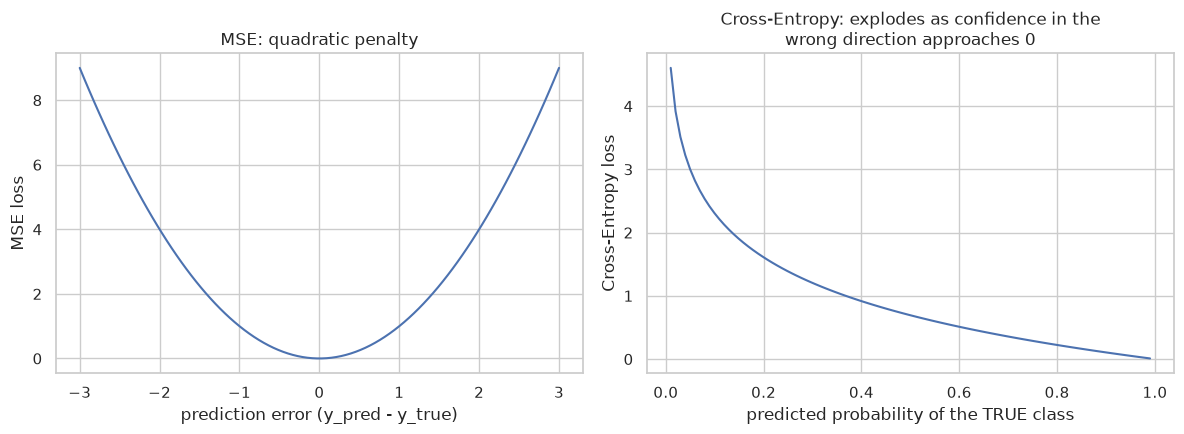

In [4]:
# MSE: penalty grows quadratically with the error
errors = torch.linspace(-3, 3, 100)
mse_values = errors ** 2

# Cross-entropy: penalty for a binary case, as a function of predicted probability of the TRUE class
probs = torch.linspace(0.01, 0.99, 100)
ce_values = -torch.log(probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(errors.numpy(), mse_values.numpy())
axes[0].set_xlabel("prediction error (y_pred - y_true)")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("MSE: quadratic penalty")

axes[1].plot(probs.numpy(), ce_values.numpy())
axes[1].set_xlabel("predicted probability of the TRUE class")
axes[1].set_ylabel("Cross-Entropy loss")
axes[1].set_title("Cross-Entropy: explodes as confidence in the\nwrong direction approaches 0")
plt.tight_layout()
plt.show()

Cross-entropy's loss shoots toward infinity as the model becomes
*confidently wrong* (predicted probability of the true class approaching
0) — a much harsher penalty than MSE would give a misclassification, which
is exactly the behavior you want for classification: confident mistakes
should hurt more than uncertain ones.

## 3. Optimizers: SGD vs. SGD+Momentum vs. Adam

**Theory.** All three use gradients from `.backward()` to update weights,
but differ in *how*:
- **SGD** — `w = w - lr * grad`. Simple, but can be slow across ravines/plateaus in the loss landscape.
- **SGD + Momentum** — accumulates a running average of past gradients, helping it push through small local bumps and accelerate in a consistent direction.
- **Adam** — adapts the effective learning rate *per parameter* based on recent gradient magnitude/variance; usually converges fastest with the least tuning, which is why it's the default choice for most modern networks.

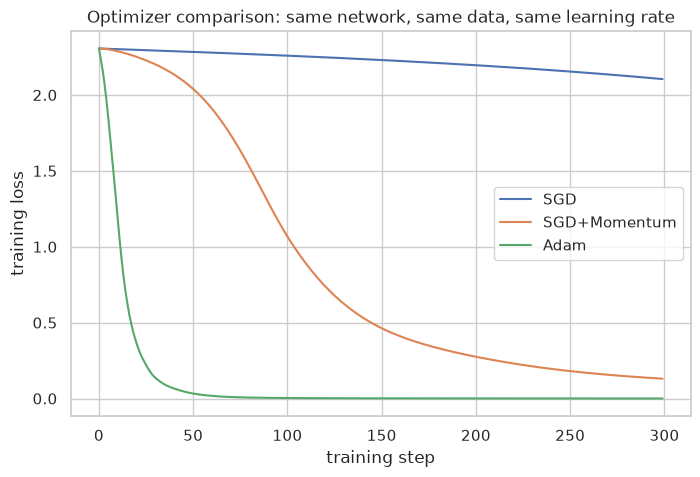

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=11, stratify=digits.target
)
scaler = StandardScaler().fit(X_train_np)
X_train = torch.tensor(scaler.transform(X_train_np), dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(scaler.transform(X_test_np), dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

def train_and_track_loss(optimizer_name, n_steps=300, lr=0.01):
    torch.manual_seed(0)
    net = MLP(in_features=64, hidden_sizes=[32, 16], n_classes=10)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    elif optimizer_name == "SGD+Momentum":
        optimizer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    losses = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        output = net(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

loss_curves = {name: train_and_track_loss(name) for name in ["SGD", "SGD+Momentum", "Adam"]}

plt.figure(figsize=(8, 5))
for name, losses in loss_curves.items():
    plt.plot(losses, label=name)
plt.xlabel("training step")
plt.ylabel("training loss")
plt.title("Optimizer comparison: same network, same data, same learning rate")
plt.legend()
plt.show()

Same architecture, same data, same learning rate, same number of steps —
the optimizer alone drives a large difference in how quickly loss drops.
This is why `torch.optim.Adam` is a very common default starting point.

## 4. The Full Training Loop: `Dataset`, `DataLoader`, Batches, Epochs

**Theory.** Real training rarely computes the loss on the entire dataset at
once (too much memory, too few weight updates per pass). Instead:
- An **epoch** is one full pass over the training data.
- A **batch** is a small chunk of that data used for one gradient update.
- `TensorDataset` + `DataLoader` handle batching and shuffling for you.

In [6]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

torch.manual_seed(11)
model = MLP(in_features=64, hidden_sizes=[32, 16], n_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30
train_losses, test_losses, test_accuracies = [], [], []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(train_dataset))

    model.eval()
    with torch.no_grad():
        test_output = model(X_test)
        test_loss = criterion(test_output, y_test).item()
        test_acc = (test_output.argmax(dim=1) == y_test).float().mean().item()
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss:  {test_losses[-1]:.4f}")
print(f"Final test accuracy: {test_accuracies[-1]:.3f}")

Final train loss: 0.0133
Final test loss:  0.0796
Final test accuracy: 0.969


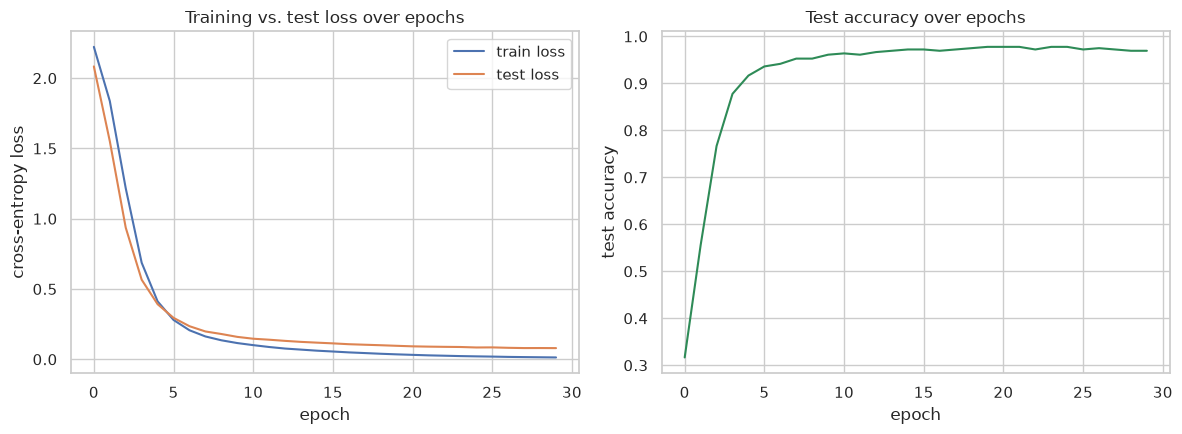

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(train_losses, label="train loss")
axes[0].plot(test_losses, label="test loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Training vs. test loss over epochs")
axes[0].legend()

axes[1].plot(test_accuracies, color="seagreen")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("test accuracy")
axes[1].set_title("Test accuracy over epochs")
plt.tight_layout()
plt.show()

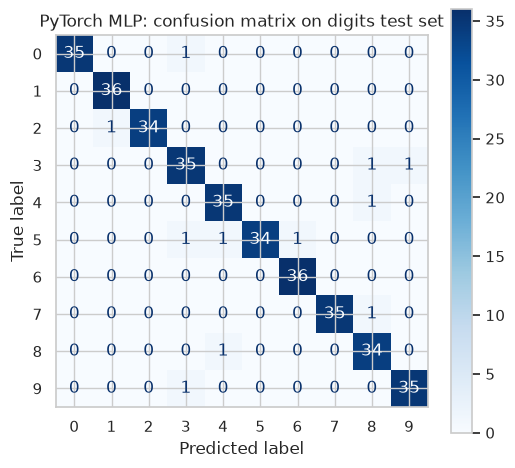

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    y_pred = model(X_test).argmax(dim=1).numpy()

fig, ax = plt.subplots(figsize=(6, 5.5))
ConfusionMatrixDisplay.from_predictions(y_test_np, y_pred, cmap="Blues", ax=ax)
ax.set_title("PyTorch MLP: confusion matrix on digits test set")
plt.show()

## 5. Comparing Against sklearn's `MLPClassifier`

Same architecture idea (2 hidden layers), same dataset, same train/test
split — a direct check of how much (if anything) hand-rolling the training
loop bought us over `08_neural_nets_intro`'s one-liner `.fit()` call.

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

sklearn_mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000, random_state=11)
sklearn_mlp.fit(scaler.transform(X_train_np), y_train_np)
sklearn_pred = sklearn_mlp.predict(scaler.transform(X_test_np))

print(f"sklearn MLPClassifier test accuracy: {accuracy_score(y_test_np, sklearn_pred):.3f}")
print(f"PyTorch MLP test accuracy:           {test_accuracies[-1]:.3f}")

sklearn MLPClassifier test accuracy: 0.964
PyTorch MLP test accuracy:           0.969


The two should land close to each other — same underlying math, same data.
The difference is entirely in *control*: PyTorch required us to write the
loop, but in exchange we can see every training/test loss per epoch, swap
optimizers freely, and (starting in Module 14) extend `nn.Module` to
architectures sklearn's MLP can't express at all.

## Exercises

1. Change the `MLP` in section 4 to 3 hidden layers `[64, 32, 16]` — does test accuracy improve, or does training loss start diverging from test loss (overfitting)?
2. Re-run the optimizer comparison in section 3 with `lr=0.1` instead of `0.01` — does plain SGD behave differently at this higher learning rate?
3. Change `batch_size` in the `DataLoader` from 32 to 256 — how does the epoch-level loss curve's smoothness change?

## Key Takeaways

- `nn.Module` packages layers + a forward pass into a reusable, inspectable object; `torchinfo.summary` gives you the architecture at a glance.
- Cross-entropy penalizes confident wrong classifications far more harshly than MSE would — use it (not MSE) for classification.
- Optimizer choice matters a lot even with everything else held fixed; Adam is a strong default for most problems.
- A training loop is just: batch the data, zero gradients, forward pass, compute loss, `.backward()`, optimizer step, repeat — every framework variant of "training a neural net" boils down to this loop.